In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import random

sys.path.append('../../')

from src.piece_functions import helix,cast_and_surge,persistent_random_walk,straight_line,generate_random_trajectory
from src.io import save_dataframe

Text(0.5, 0.92, 'cast and surge')

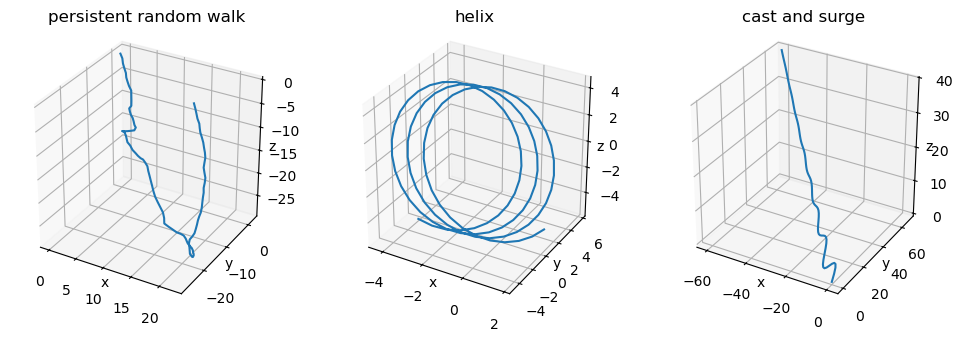

In [2]:
n_steps = 100
A = 1.
B = 1.
w = 0.01
step_size=1
#x, y, z = periodic_behavior_3d([0,0,0], n_steps, A=A, B=B, w=w, dt=step_size)
#x,y,z = cast_and_surge_3d([0,0,0],60,A0=5,decay=0.05,freq=0.5)

fig,ax = plt.subplots(ncols=3, figsize=(12,4),subplot_kw={'projection':'3d'})

x,y,z = persistent_random_walk([0.,0.,0.],n_steps=n_steps,turn_std=np.pi/10)
ax[0].plot(x,y,z)

x,y,z = helix([0.,0.,0.],n_steps=n_steps)
ax[1].plot(x,y,z)

x,y,z = cast_and_surge([0.,0.,0.],n_steps=n_steps)
ax[2].plot(x,y,z)

for i in range(3):
    ax[i].set_xlabel('x',labelpad=-15)
    ax[i].set_ylabel('y',labelpad=-15)
    ax[i].set_zlabel('z',labelpad=-15)
    #ax[i].set_xticklabels([])
    #ax[i].set_yticklabels([])
    #ax[i].set_zticklabels([])
    ax[i].grid(True)
    ax[i].set_box_aspect([1, 1, 1])
ax[0].set_title('persistent random walk')
ax[1].set_title('helix')
ax[2].set_title('cast and surge')

#fig.savefig('stereotypes.svg')

In [3]:
ttot = 2000
mvt_types = ['straight','persistent_random_walk','helix','persistent_random_walk','cast_and_surge']
mvt_args = {'straight':{'n_steps':50,'step':2.,'distrib':'uniform'},'helix':{'radius':5,'pitch':5.,'distrib':'uniform'},'cast_and_surge':{'A0':10,'decay':0.025,'distrib':'unform'},'persistent_random_walk':{'turn_std':np.pi/5,'distrib':'uniform'}}
trj, move_names = generate_random_trajectory(total_steps = ttot,
                                                step_size=1.,
                                                mvt_types = mvt_types,
                                                mvt_args=mvt_args)

In [5]:
trj.shape

(2000, 3)

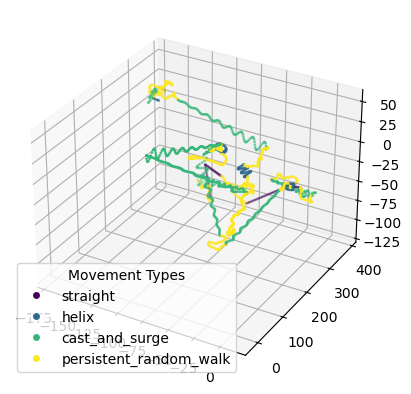

In [4]:
cmap = colormaps['viridis']
clr_dict ={'straight':cmap(0.),'helix':cmap(0.333),'cast_and_surge':cmap(0.666),'persistent_random_walk':cmap(1.)}
color_code = np.array([clr_dict[mv] for mv in move_names])
fig,ax = plt.subplots(subplot_kw={'projection':'3d'})
ax.scatter(trj[:,0],trj[:,1],trj[:,2],c=color_code,s=1)


legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=key,
           markerfacecolor=color, markersize=6)
    for key, color in clr_dict.items()
]

ax.legend(handles=legend_elements, title="Movement Types")
#fig.savefig('trajectory_example.svg',bbox_inches='tight')

In [6]:
generate_random_trajectory(total_steps = ttot,
                                                    step_size=1.,
                                                    mvt_types = mvt_types0,
                                                    mvt_args=mvt_args)

NameError: name 'mvt_types0' is not defined

In [3]:
A = 0.1
ttot = 1000
nsample = 100
trjs,moves = np.zeros((nsample,ttot,3),dtype=float),np.zeros((nsample,ttot),dtype='U25')
mvt_types = ['helix','straight']
mvt_args = {'straight':{'n_steps':50,'step':2.},'helix':{'radius':5,'pitch':5.}}

for i in range(nsample):
    noise = np.array([np.random.randint(0,1000,ttot)/1000 * A,np.random.randint(0,1000,ttot)/1000 * A,np.random.randint(0,1000,ttot)/1000 * A]).T

    trjs[i],moves[i] = generate_random_trajectory(total_steps = ttot,step_size=1.,mvt_types = mvt_types,mvt_args=mvt_args)
    trjs[i]+=noise

labels = np.repeat(np.arange(nsample), ttot)
frames = np.tile(np.arange(ttot), nsample)

flat_trjs = trjs.reshape(-1, 3)
flat_moves = [item for sublist in moves for item in sublist]

df = pd.DataFrame(flat_trjs, columns=['x', 'y', 'z'])

df['label'] = labels
df['frame'] = frames
df['move_type'] = flat_moves

save_dataframe(df,"../../data/toy_model/raw/straight_helix.parquet")

In [7]:
A = 0.1
ttot = 1000
nsample = 100
trjs0,moves0 = np.zeros((nsample,ttot,3),dtype=float),np.zeros((nsample,ttot),dtype='U25')
trjs1,moves1 = np.zeros((nsample,ttot,3),dtype=float),np.zeros((nsample,ttot),dtype='U25')
trjs2,moves2 = np.zeros((nsample,ttot,3),dtype=float),np.zeros((nsample,ttot),dtype='U25')

mvt_types0 = ['persistent_random_walk']
mvt_types1 = ['straight','persistent_random_walk','helix','persistent_random_walk','cast_and_surge']
mvt_types2 = ['straight','persistent_random_walk']

mvt_args = {'straight':{'n_steps':50,'step':2.},'helix':{'radius':5,'pitch':5.},'cast_and_surge':{'A0':10,'decay':0.025},'persistent_random_walk':{'turn_std':np.pi/5}}

for i in range(nsample):
    noise = np.array([np.random.randint(0,1000,ttot)/1000 * A,np.random.randint(0,1000,ttot)/1000 * A,np.random.randint(0,1000,ttot)/1000 * A]).T

    trjs0[i],moves0[i] = generate_random_trajectory(total_steps = ttot,step_size=1.,mvt_types = mvt_types0,mvt_args=mvt_args)
    trjs1[i],moves1[i] = generate_random_trajectory(total_steps = ttot,step_size=1.,mvt_types = mvt_types1,mvt_args=mvt_args)
    trjs2[i],moves2[i] = generate_random_trajectory(total_steps = ttot,step_size=1.,mvt_types = mvt_types2,mvt_args=mvt_args)
    trjs0[i]+=noise
    trjs1[i]+=noise
    trjs2[i]+=noise

# Create flattened arrays

labels = np.repeat(np.arange(nsample), ttot)
frames = np.tile(np.arange(ttot), nsample)

flat_trjs0 = trjs0.reshape(-1, 3)
flat_trjs1 = trjs1.reshape(-1, 3)
flat_trjs2 = trjs2.reshape(-1, 3)

flat_moves0 = [item for sublist in moves0 for item in sublist]
flat_moves1 = [item for sublist in moves1 for item in sublist]
flat_moves2 = [item for sublist in moves2 for item in sublist]

# Assemble into DataFrame
df0 = pd.DataFrame(flat_trjs0, columns=['x', 'y', 'z'])
df1 = pd.DataFrame(flat_trjs1, columns=['x', 'y', 'z'])
df2 = pd.DataFrame(flat_trjs2, columns=['x', 'y', 'z'])

df0['label'] = labels
df0['frame'] = frames
df0['move_type'] = flat_moves0

df1['label'] = labels
df1['frame'] = frames
df1['move_type'] = flat_moves1

df2['label'] = labels
df2['frame'] = frames
df2['move_type'] = flat_moves2

In [8]:
save_dataframe(df0,"../../data/toy_model/raw/only_persistent.parquet")
save_dataframe(df1,"../../data/toy_model/raw/stereotypes4.parquet")
save_dataframe(df2,"../../data/toy_model/raw/stereotypes2.parquet")


# Illustrate the canonicalize function

In [9]:
def canonicalize_trajectory(coords, *, return_rotation=False, tol=1e-12):
    """
    Rotate `coords` (K×3) into a unique canonical frame.
    Any rigid-body rotation + translation of the same trajectory
    maps to the *identical* output.

    Algorithm
    ---------
    1.  centre at the centroid
    2.  PCA → eigenvectors V (columns)
    3.  for each axis j:                       # sign disambiguation
        m3 = Σ (x_j')³   (third central moment)
        if |m3| < tol use   Σ x_j'² x_{j+1}'
        flip V[:,j] if m3 < 0
    4.  make the basis right-handed (det = +1)
    5.  rotated = centred @ V

    Returns
    -------
    canon : (K,3)  canonical coordinates (centroid at the origin)
    R      : (3,3) rotation matrix  (only if `return_rotation=True`)
    """

    X   = np.asarray(coords, dtype=float)
    C   = X - X.mean(axis=0)               # 1
    _,  _, Vt = np.linalg.svd(C, full_matrices=False)
    V   = Vt.T                             # 2

    Y   = C @ V                            # projections for moments
    for j in range(3):                     # 3
        m3 = (Y[:, j] ** 3).sum()
        if abs(m3) < tol:                  # nearly symmetric
            k = (j + 1) % 3
            m3 = (Y[:, j]**2 * Y[:, k]).sum()
        if m3 < 0:
            V[:, j] *= -1
            Y[:, j] *= -1

    if np.linalg.det(V) < 0:               # 4
        V[:, 2] *= -1
        Y[:, 2] *= -1

    canon = Y                               # 5
    ## Step 6: chiral disambiguation via lexicographic minimization
    mirrors = np.array([
        [ 1,  1,  1],
        [-1,  1,  1],
        [ 1, -1,  1],
        [ 1,  1, -1],
        [-1, -1,  1],
        [-1,  1, -1],
        [ 1, -1, -1],
        [-1, -1, -1]
    ])  # shape (8, 3)

    mirrored = np.einsum('ij,kj->kij', canon, mirrors)  #µ shape (8, K, 3)

    flat = mirrored.reshape(8, -1)  # shape (8, 3K)
    best_index = np.lexsort(flat.T)[0]
    canon = mirrored[best_index]

    return (canon, V) if return_rotation else canon

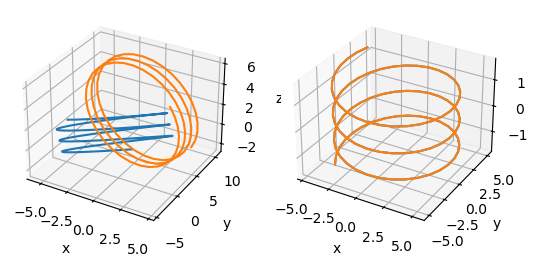

In [11]:
x1,y1,z1 =  helix(start = np.array([0.,0.,0.]), n_steps=100, radius=5, pitch=1.0, clockwise=True, step=1.0)
x2,y2,z2 =  helix(start = np.array([1.,5.,3.]), n_steps=100, radius=5, pitch=-1.0, clockwise=False, step=1.0)
fig,ax = plt.subplots(ncols= 2,subplot_kw={"projection":'3d'})
ax[0].plot(x1,y1,z1)
ax[0].plot(x2,y2,z2)

xyz1 = canonicalize_trajectory(np.array([x1,y1,z1]).T)
xyz2 = canonicalize_trajectory(np.array([x2,y2,z2]).T)

ax[1].plot(xyz1[:,0],xyz1[:,1],xyz1[:,2])
ax[1].plot(xyz2[:,0],xyz2[:,1],xyz2[:,2])
for i in range(2):
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('y')
    ax[i].set_zlabel('z')
fig.savefig('helix_disambiguation.pdf',bbox_inches='tight')